In [ ]:
python machine_learning_restaurants.py


✅ Dataset Loaded Successfully: (9551, 21)

🧩 TASK 1 : Predict Restaurant Ratings
MAE : 1.105
R2 Score : 0.227

🧩 TASK 2 : Restaurant Recommendation System

🍽 Recommended Restaurants for Domino'S Pizza:

Flying Pie Pizzaria
Guido's Original New York Style Pizza
Mellow Mushroom
That Baat
Kareem's Kabab & Biryani

🧩 TASK 3 : Restaurant Segmentation
✅ Clustering Completed


C:\Users\faija\AppData\Local\Temp\ipykernel_7296\3086396497.py:198: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\faija\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


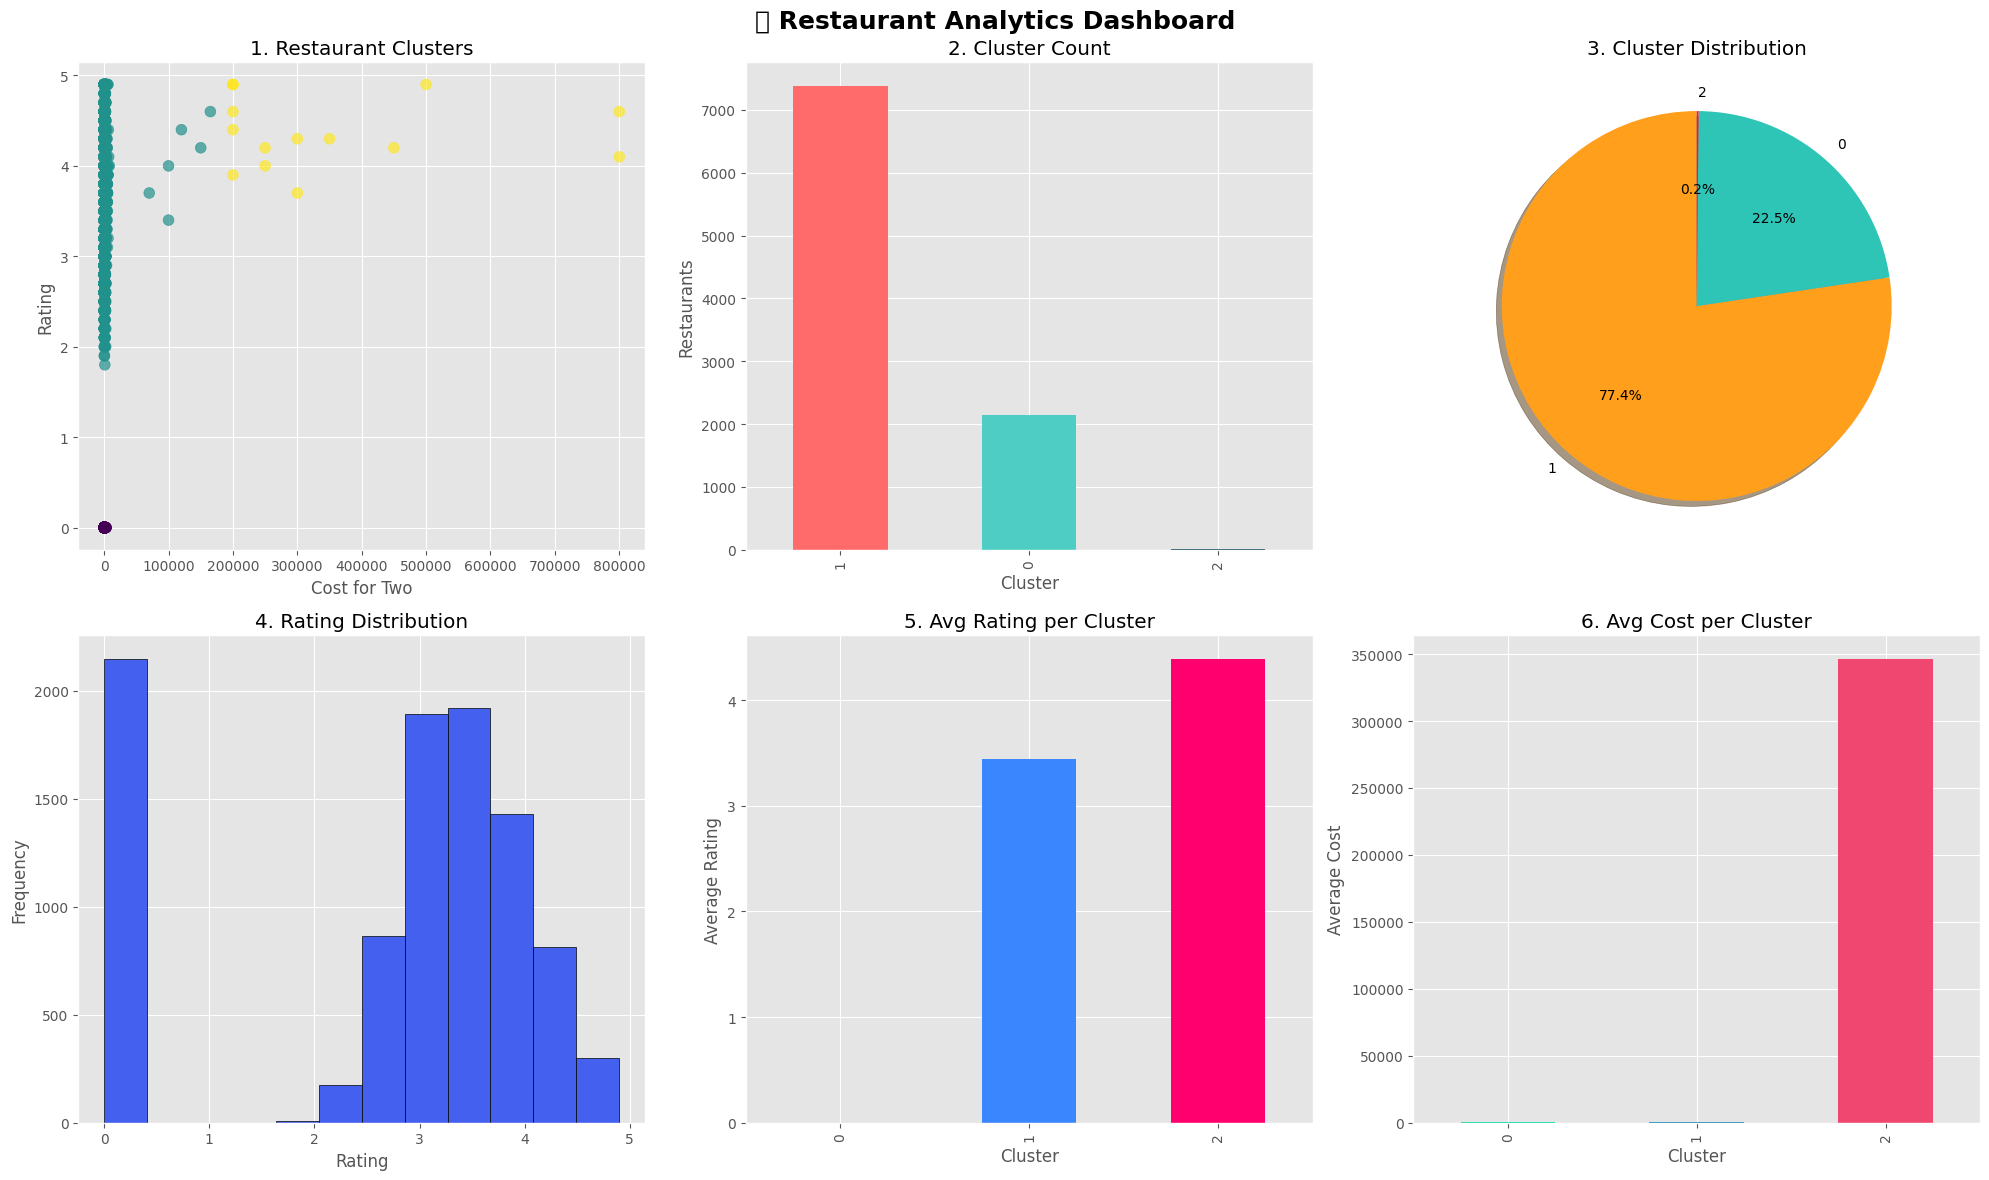


🎉 ALL TASKS COMPLETED SUCCESSFULLY


In [19]:
# ==========================================================
# 🍽 COGNIFYZ RESTAURANT ML PROJECT
# ALL TASKS COMPLETE CODE (Fresh + Professional)
# Task 1: Predict Restaurant Ratings
# Task 2: Restaurant Recommendation System
# Task 3: Restaurant Segmentation + Dashboard
# ==========================================================

# ----------------------------
# Import Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv("restaurants.csv")

# Clean Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Dataset Loaded Successfully:", df.shape)

# ==========================================================
# 🧩 TASK 1 : Predict Restaurant Ratings
# ==========================================================

print("\n🧩 TASK 1 : Predict Restaurant Ratings")

# Features
X = df[['average_cost_for_two', 'price_range', 'votes']]

# Target
y = df['aggregate_rating']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
print("R2 Score :", round(r2_score(y_test, y_pred), 3))

# ==========================================================
# 🧩 TASK 2 : Restaurant Recommendation System
# ==========================================================

print("\n🧩 TASK 2 : Restaurant Recommendation System")

# Create Combined Features
df['combined_features'] = df['cuisines'].astype(str) + " " + df['city'].astype(str)

# Convert Text to Matrix
cv = CountVectorizer()
matrix = cv.fit_transform(df['combined_features'])

# Similarity Matrix
similarity = cosine_similarity(matrix)

# Recommendation Function
def recommend_restaurant(name):
    
    name = name.lower()

    if name not in df['restaurant_name'].str.lower().values:
        print("❌ Restaurant Not Found")
        return

    index = df[df['restaurant_name'].str.lower() == name].index[0]

    scores = list(enumerate(similarity[index]))
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]

    print(f"\n🍽 Recommended Restaurants for {name.title()}:\n")

    for i in sorted_scores:
        print(df.iloc[i[0]]['restaurant_name'])

# Example
recommend_restaurant("domino's pizza")

# ==========================================================
# 🧩 TASK 3 : Restaurant Segmentation
# ==========================================================

print("\n🧩 TASK 3 : Restaurant Segmentation")

# Select Features
features = df[['average_cost_for_two', 'aggregate_rating', 'votes']]

# Scale Data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

print("✅ Clustering Completed")

# ==========================================================
# 📊 PROFESSIONAL DASHBOARD
# ==========================================================

plt.style.use("ggplot")

fig = plt.figure(figsize=(20,12))
fig.suptitle("🍽 Restaurant Analytics Dashboard", fontsize=18, fontweight='bold')

# 1 Scatter Plot
plt.subplot(2,3,1)
plt.scatter(
    df['average_cost_for_two'],
    df['aggregate_rating'],
    c=df['cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7
)
plt.title("1. Restaurant Clusters")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")

# 2 Bar Chart
plt.subplot(2,3,2)
df['cluster'].value_counts().plot(
    kind='bar',
    color=['#ff6b6b','#4ecdc4','#1a535c']
)
plt.title("2. Cluster Count")
plt.xlabel("Cluster")
plt.ylabel("Restaurants")

# 3 Pie Chart
plt.subplot(2,3,3)
df['cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=['#ff9f1c','#2ec4b6','#e71d36']
)
plt.title("3. Cluster Distribution")
plt.ylabel("")

# 4 Histogram
plt.subplot(2,3,4)
plt.hist(
    df['aggregate_rating'],
    bins=12,
    color='#4361ee',
    edgecolor='black'
)
plt.title("4. Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

# 5 Avg Rating per Cluster
plt.subplot(2,3,5)
df.groupby('cluster')['aggregate_rating'].mean().plot(
    kind='bar',
    color=['#8338ec','#3a86ff','#ff006e']
)
plt.title("5. Avg Rating per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Rating")

# 6 Avg Cost per Cluster
plt.subplot(2,3,6)
df.groupby('cluster')['average_cost_for_two'].mean().plot(
    kind='bar',
    color=['#06d6a0','#118ab2','#ef476f']
)
plt.title("6. Avg Cost per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Cost")

plt.tight_layout()
plt.show()

# ==========================================================
# ✅ PROJECT COMPLETED
# ==========================================================
print("\n🎉 ALL TASKS COMPLETED SUCCESSFULLY")

In [ ]:
dir


In [ ]:
import os
import pandas as pd

base_path = os.path.dirname(__file__)
file_path = os.path.join(base_path, "restaurants.csv")

df = pd.read_csv(file_path)

print(df.head())

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

In [ ]:
import pandas as pd
df = pd.read_csv("restaurants.csv")
print(df.head())


In [ ]:
import os
print(os.listdir())

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\faija\OneDrive\Documents\restaurants.csv")
print(df.head())

In [ ]:
import os
print(os.listdir(r"C:\Users\faija\OneDrive\Documents"))

In [ ]:
import os
print(os.listdir(r"C:\Users\faija\OneDrive\Documents"))

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

In [2]:
for col in df.columns:
    print(col)

Restaurant ID
Restaurant Name
Country Code
City
Address
Locality
Locality Verbose
Longitude
Latitude
Cuisines
Average Cost for two
Currency
Has Table booking
Has Online delivery
Is delivering now
Switch to order menu
Price range
Aggregate rating
Rating color
Rating text
Votes
main_cuisine


In [3]:
df = pd.read_csv("restaurants.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='object')


In [4]:
df = pd.read_csv("restaurants.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
import pandas as pd

df = pd.read_csv("restaurants.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Data Loaded:", df.shape)
print(df.columns)

✅ Data Loaded: (9551, 21)
Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='object')


In [6]:
df1 = df.dropna(subset=['aggregate_rating'])

X1 = df1[['average_cost_for_two', 'price_range', 'votes']]
y1 = df1['aggregate_rating']

In [7]:
import pandas as pd

df = pd.read_csv("restaurants.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [8]:
# 🧩 TASK 1: Predict Restaurant Ratings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features
X = df[['average_cost_for_two', 'price_range', 'votes']]

# Target
y = df['aggregate_rating']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("📌 TASK 1: Predict Restaurant Ratings")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

📌 TASK 1: Predict Restaurant Ratings
MAE: 1.1047971958808969
R2 Score: 0.226781209472952


In [11]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'main_cuisine'],
      dtype='object')


In [12]:
import pandas as pd

df = pd.read_csv("restaurants.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='object')


In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine features
df['combined_features'] = df['cuisines'].astype(str) + " " + df['city'].astype(str)

# Convert text into matrix
cv = CountVectorizer()
matrix = cv.fit_transform(df['combined_features'])

# Similarity matrix
similarity = cosine_similarity(matrix)

# Recommendation Function
def recommend(name):
    name = name.lower()
    
    if name not in df['restaurant_name'].str.lower().values:
        print("Restaurant not found")
        return
    
    index = df[df['restaurant_name'].str.lower() == name].index[0]

    scores = list(enumerate(similarity[index]))
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]

    print("🍽 Recommended Restaurants:")
    for i in sorted_scores:
        print(df.iloc[i[0]]['restaurant_name'])

# Example
recommend("domino's pizza")

🍽 Recommended Restaurants:
Flying Pie Pizzaria
Guido's Original New York Style Pizza
Mellow Mushroom
That Baat
Kareem's Kabab & Biryani


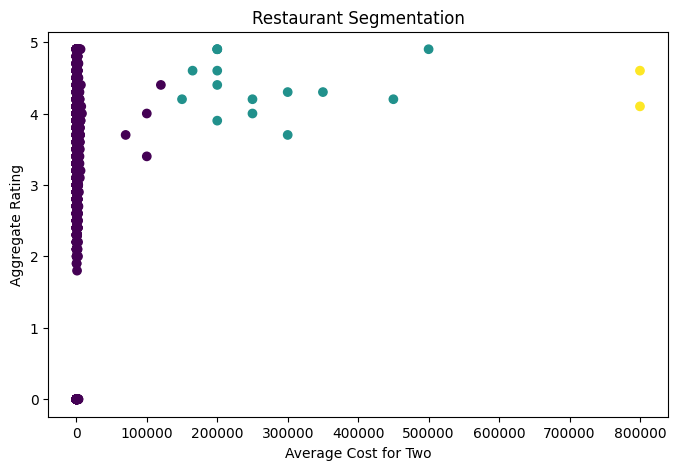

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Features
X = df[['average_cost_for_two', 'aggregate_rating', 'votes']]

# KMeans Model
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df['average_cost_for_two'], df['aggregate_rating'], c=df['cluster'])
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.title("Restaurant Segmentation")
plt.show()

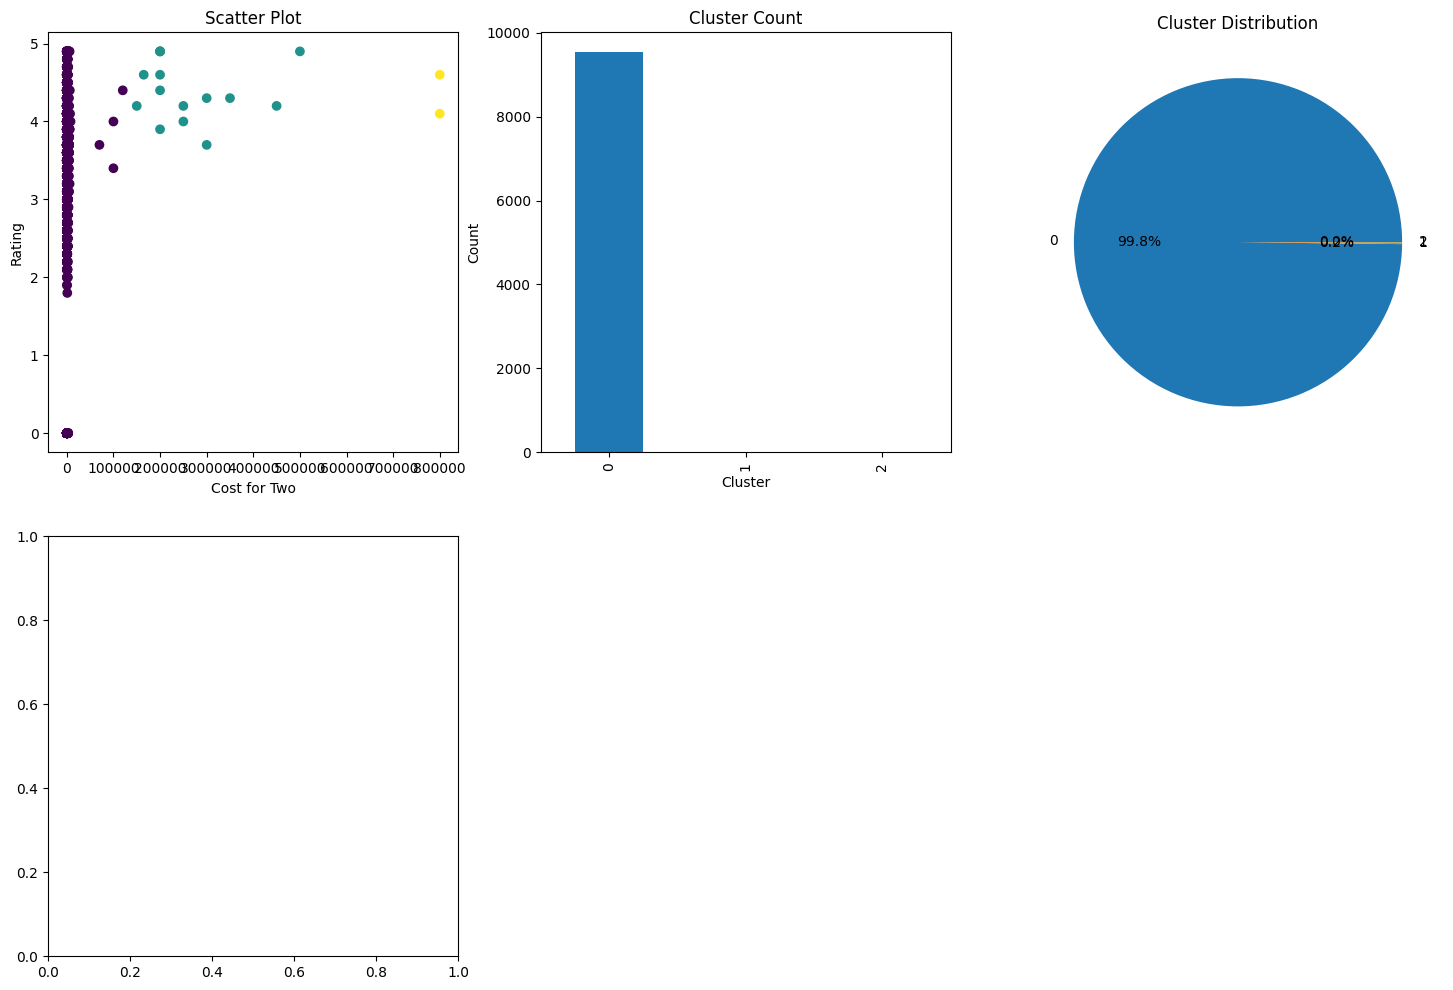

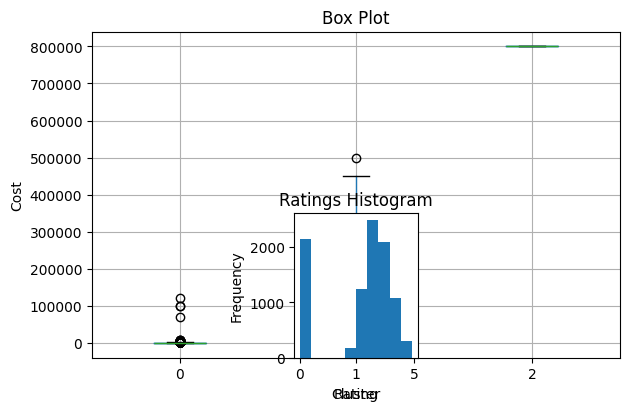

In [18]:
# 🧩 TASK 3 - All 5 Charts Together

import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))

# 1️⃣ Scatter Plot
plt.subplot(2,3,1)
plt.scatter(df['average_cost_for_two'], df['aggregate_rating'], c=df['cluster'])
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.title("Scatter Plot")

# 2️⃣ Bar Chart
plt.subplot(2,3,2)
df['cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Count")
plt.xlabel("Cluster")
plt.ylabel("Count")

# 3️⃣ Pie Chart
plt.subplot(2,3,3)
df['cluster'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Cluster Distribution")
plt.ylabel("")

# 4️⃣ Box Plot
plt.subplot(2,3,4)
df.boxplot(column='average_cost_for_two', by='cluster')
plt.title("Box Plot")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Cost")

# 5️⃣ Histogram
plt.subplot(2,3,5)
plt.hist(df['aggregate_rating'], bins=10)
plt.title("Ratings Histogram")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()# 🧩 TASK 3 - Professional & Colorful Charts Together

import matplotlib.pyplot as plt

plt.style.use('ggplot')   # Professional style

fig = plt.figure(figsize=(20,12))

# 1️⃣ Scatter Plot
plt.subplot(2,3,1)
plt.scatter(
    df['average_cost_for_two'],
    df['aggregate_rating'],
    c=df['cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.title("Restaurant Segmentation", fontsize=12, fontweight='bold')

# 2️⃣ Bar Chart
plt.subplot(2,3,2)
df['cluster'].value_counts().plot(
    kind='bar',
    color=['#ff6b6b','#4ecdc4','#1a535c']
)
plt.title("Restaurants per Cluster", fontsize=12, fontweight='bold')
plt.xlabel("Cluster")
plt.ylabel("Count")

# 3️⃣ Pie Chart
plt.subplot(2,3,3)
df['cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ff9f1c','#2ec4b6','#e71d36'],
    startangle=90,
    shadow=True
)
plt.title("Cluster Distribution", fontsize=12, fontweight='bold')
plt.ylabel("")

# 4️⃣ Box Plot
plt.subplot(2,3,4)
df.boxplot(
    column='average_cost_for_two',
    by='cluster',
    patch_artist=True,
    boxprops=dict(facecolor='#74c69d'),
    medianprops=dict(color='red', linewidth=2)
)
plt.title("Cost Distribution by Cluster", fontsize=12, fontweight='bold')
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Average Cost")

# 5️⃣ Histogram
plt.subplot(2,3,5)
plt.hist(
    df['aggregate_rating'],
    bins=12,
    color='#4361ee',
    edgecolor='black'
)
plt.title("Ratings Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Frequency")

# Empty last subplot for spacing
plt.subplot(2,3,6)
plt.axis('off')

plt.tight_layout()
plt.show()